In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
from sklearn.feature_selection import SelectKBest

In [79]:
root_path = "/home/stefan/ioai-prep/kits/diamante"
seed = 42

# Data

In [80]:
pt = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)
poly = PolynomialFeatures()
kb = SelectKBest()

def carat2str(carat):
    if carat < 0.5:
        return "Light"
    if carat < 1.5:
        return "Medium"
    return "Heavy"

In [ ]:
def prep_df(df: pd.DataFrame):
    df = df.drop(["SampleID", "price"], axis=1, errors="ignore")

    # ordinal encoding for ordered categoricals
    cut_map = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5}
    color_map = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
    clarity_map = {
        "I3": 1,
        "I2": 2,
        "I1": 3,
        "SI2": 4,
        "SI1": 5,
        "VS2": 6,
        "VS1": 7,
        "VVS2": 8,
        "VVS1": 9,
        "IF": 10,
        "FL": 11,
    }
    df["cut"] = df["cut"].map(cut_map).astype("int")
    df["color"] = df["color"].map(color_map).astype("int")
    df["clarity"] = df["clarity"].map(clarity_map).astype("int")

    # little poly feature
    df["carat2"] = df["carat"] ** 2

    # volume and volume-per-carat
    df["volume"] = df["x"] * df["y"] * df["z"]
    df["vol_per_carat"] = df["volume"] / (df["carat"] + 1e-6)

    # other existing helpers
    df["dt"] = df["depth"] / df["table"]

    return df

In [82]:
df = pd.read_csv(f"{root_path}/train.csv")
df_train = prep_df(df)

In [83]:
df_train.head()

,carat,cut,color,clarity,depth,table,x,y,z,carat2,volume,vol_per_carat,dt
0,1.21,5,3,8,61.3,57.0,6.92,6.87,4.23,1.4641,201.095892,166.194815,1.075439
1,0.31,5,6,6,62.0,56.0,4.38,4.36,2.71,0.0961,51.752328,166.942455,1.107143
2,1.21,5,6,7,62.4,57.0,6.75,6.83,4.24,1.4641,195.474600,161.549123,1.094737
3,0.81,5,5,4,62.6,55.0,5.92,5.96,3.72,0.6561,131.253504,162.041163,1.138182
4,0.79,5,2,8,61.7,56.0,5.94,5.95,3.67,0.6241,129.708810,164.188159,1.101786


# EDA

In [84]:
df["cut"].value_counts()

cut
Ideal        15064
Premium       9649
Very Good     8516
Good          3406
Fair          1123
Name: count, dtype: int64

<Axes: >

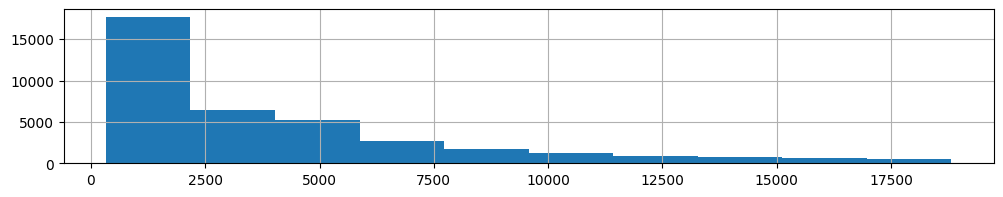

In [85]:
plt.figure(figsize=(12, 2))
df["price"].hist()

<Axes: >

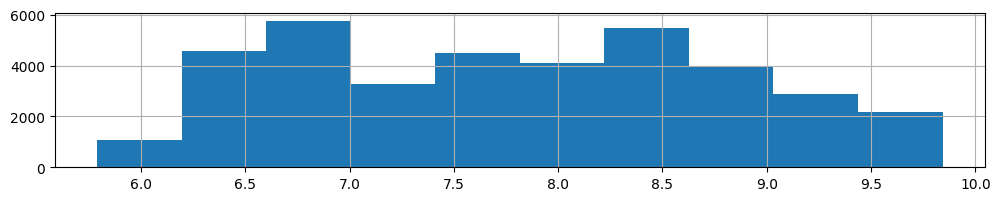

In [86]:
plt.figure(figsize=(12, 2))
df["price"].apply(np.log1p).hist()

In [87]:
df_train.corrwith(df["price"]).sort_values(ascending=False)

carat            0.921729
volume           0.895470
carat2           0.889385
x                0.884821
y                0.863298
z                0.855583
table            0.122367
depth           -0.004225
vol_per_carat   -0.053349
cut             -0.056111
dt              -0.097893
clarity         -0.145087
color           -0.172809
dtype: float64

# Models

In [88]:
X_train, X_test, y_train, y_test = train_test_split(df_train, df["price"], test_size=0.2, random_state=seed)

In [ ]:
# log transform
y_train = pt.transform(y_train)
y_test = pt.transform(y_test)

In [90]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    cv = cv.mean() - cv.std()
    return -cv.item()

In [91]:
ridge = Ridge()

evaluate(ridge)

0.11197200805423811

In [92]:
cb = CatBoostRegressor(max_depth=10, iterations=2000, random_state=seed)

evaluate(cb)

Learning rate set to 0.037452
Learning rate set to 0.037452
Learning rate set to 0.037452
0:	learn: 0.9791391	total: 30.8ms	remaining: 1m 1s
0:	learn: 0.9797894	total: 30.2ms	remaining: 1m
0:	learn: 0.9817093	total: 43.4ms	remaining: 1m 26s
1:	learn: 0.9456870	total: 60.5ms	remaining: 1m
1:	learn: 0.9450606	total: 71.5ms	remaining: 1m 11s
1:	learn: 0.9475929	total: 77.1ms	remaining: 1m 17s
2:	learn: 0.9128730	total: 78.1ms	remaining: 52s
2:	learn: 0.9122866	total: 113ms	remaining: 1m 15s
3:	learn: 0.8816149	total: 109ms	remaining: 54.2s
2:	learn: 0.9147329	total: 116ms	remaining: 1m 17s
4:	learn: 0.8509031	total: 137ms	remaining: 54.6s
3:	learn: 0.8810416	total: 147ms	remaining: 1m 13s
3:	learn: 0.8833937	total: 158ms	remaining: 1m 18s
4:	learn: 0.8503302	total: 183ms	remaining: 1m 13s
5:	learn: 0.8217477	total: 185ms	remaining: 1m 1s
4:	learn: 0.8524992	total: 197ms	remaining: 1m 18s
5:	learn: 0.8211801	total: 218ms	remaining: 1m 12s
6:	learn: 0.7940451	total: 221ms	remaining: 1m 2s
5

0.0626646150253213

In [93]:
model = cb

model.fit(X_train, y_train)

Learning rate set to 0.03993
0:	learn: 0.9778476	total: 19.9ms	remaining: 39.7s
1:	learn: 0.9415139	total: 47.7ms	remaining: 47.6s
2:	learn: 0.9062467	total: 69.3ms	remaining: 46.1s
3:	learn: 0.8729941	total: 87.5ms	remaining: 43.7s
4:	learn: 0.8405464	total: 103ms	remaining: 41.1s
5:	learn: 0.8094956	total: 120ms	remaining: 39.8s
6:	learn: 0.7797479	total: 139ms	remaining: 39.6s
7:	learn: 0.7508969	total: 159ms	remaining: 39.5s
8:	learn: 0.7233276	total: 173ms	remaining: 38.2s
9:	learn: 0.6969542	total: 199ms	remaining: 39.5s
10:	learn: 0.6719627	total: 210ms	remaining: 37.9s
11:	learn: 0.6473568	total: 226ms	remaining: 37.4s
12:	learn: 0.6242595	total: 238ms	remaining: 36.3s
13:	learn: 0.6019324	total: 251ms	remaining: 35.6s
14:	learn: 0.5805211	total: 265ms	remaining: 35.1s
15:	learn: 0.5602520	total: 280ms	remaining: 34.7s
16:	learn: 0.5405846	total: 292ms	remaining: 34.1s
17:	learn: 0.5220242	total: 306ms	remaining: 33.7s
18:	learn: 0.5037547	total: 324ms	remaining: 33.8s
19:	lear

# Submission

In [94]:
df_test_ = pd.read_csv(f"{root_path}/test.csv")
df_test = prep_df(df_test_)

In [95]:
subtask1 = df_test_["carat"].map(carat2str)

In [96]:
subtask2 = df_test["depth"] / df_test["table"]

In [97]:
subtask3 = df_test["x"] * df_test["y"] * df_test["z"]

In [98]:
# X_test_fr = poly.transform(df_test)

subtask4 = model.predict(df_test)
subtask4 = pt.inverse_transform(subtask4)

In [99]:
subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3),
    (4, subtask4),
]


def build_subtask(sid, answer):
    return pd.DataFrame(
        {"subtaskID": sid, "datapointID": df_test_["SampleID"], "answer": answer}
    )


submission = pd.concat([build_subtask(sid, ans) for sid, ans in subtasks])
submission.head()

,subtaskID,datapointID,answer
0,1,1389,Light
1,1,50053,Medium
2,1,41646,Light
3,1,42378,Light
4,1,17245,Heavy


In [100]:
submission.to_csv(f"{root_path}/submission.csv", index=False)